In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("C:/Users/fdcontreras/Downloads/datos.csv")


In [4]:
# 1.1 Convertir fechas a datetime
fecha_cols = [
    "order_purchase_timestamp", "order_approved_at", 
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "review_creation_date",
    "review_answer_timestamp", "shipping_limit_date"
]
for col in fecha_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [5]:
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category_name_english      2567
product_name_lenght                2542
product_photos_qty                 2542
product_description_lenght         2542
product_category_name              2542
order_delivered_carrier_date       2086
geolocation_lat                    1098
dtype: int64

In [6]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
pd.DataFrame({"nulos": nulos, "%": pct_nulos}).sort_values("%", ascending=False)

,nulos,%
review_comment_title,105154,88.258647
review_comment_message,68898,57.827988
order_delivered_customer_date,3421,2.871339
product_category_name_english,2567,2.154554
product_name_lenght,2542,2.133571
product_photos_qty,2542,2.133571
product_description_lenght,2542,2.133571
product_category_name,2542,2.133571
order_delivered_carrier_date,2086,1.750837
geolocation_lat,1098,0.921582


In [7]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

# Descriptivos
print(df[num_cols].describe())

       customer_zip_code_prefix  payment_sequential  payment_installments  \
count             119143.000000       119140.000000         119140.000000   
mean               35033.451298            1.094737              2.941246   
std                29823.198969            0.730141              2.777848   
min                 1003.000000            1.000000              0.000000   
25%                11250.000000            1.000000              1.000000   
50%                24240.000000            1.000000              2.000000   
75%                58475.000000            1.000000              4.000000   
max                99990.000000           29.000000             24.000000   

       payment_value   review_score  order_item_id          price  \
count  119140.000000  118146.000000  118310.000000  118310.000000   
mean      172.735135       4.015582       1.196543     120.646603   
std       267.776077       1.400436       0.699489     184.109691   
min         0.000000       1.0

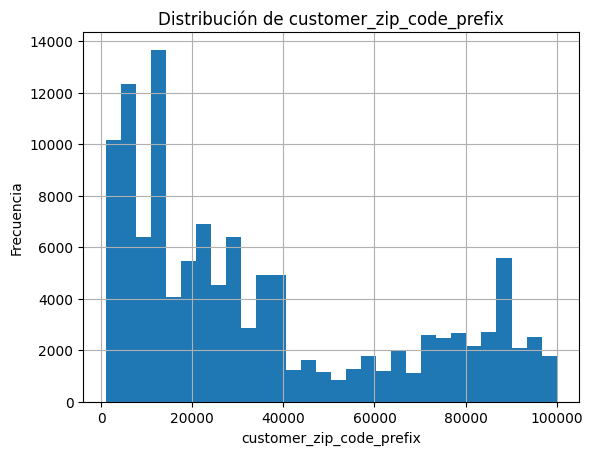

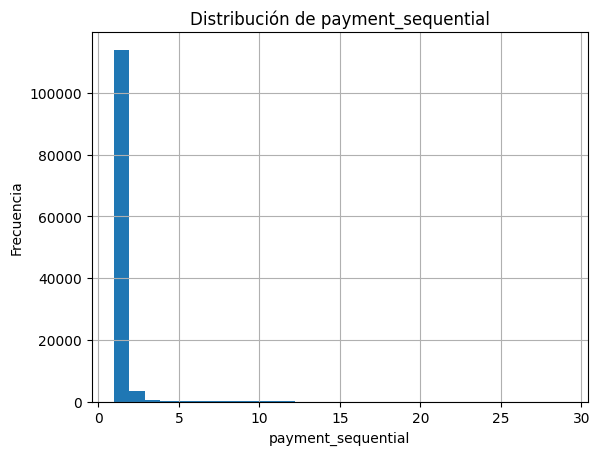

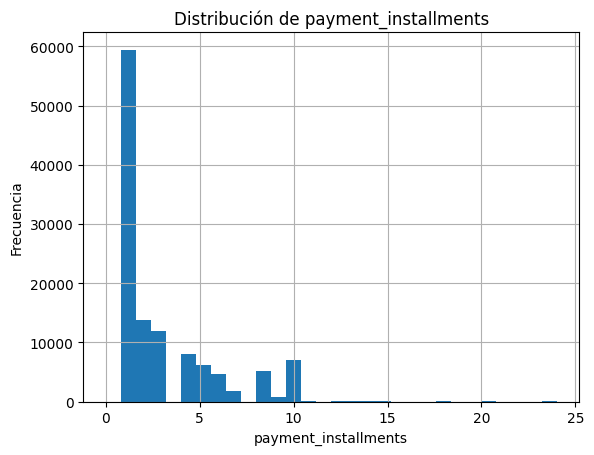

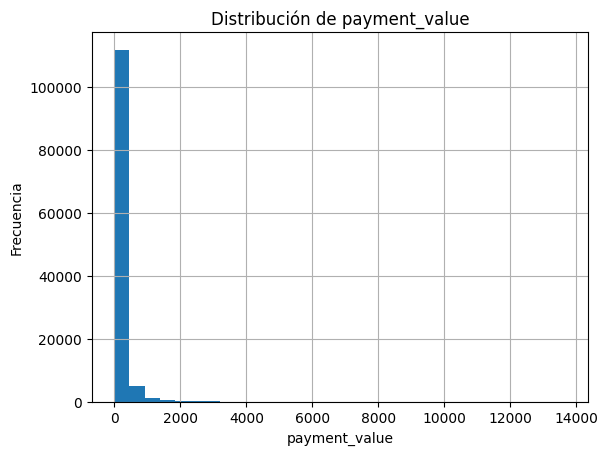

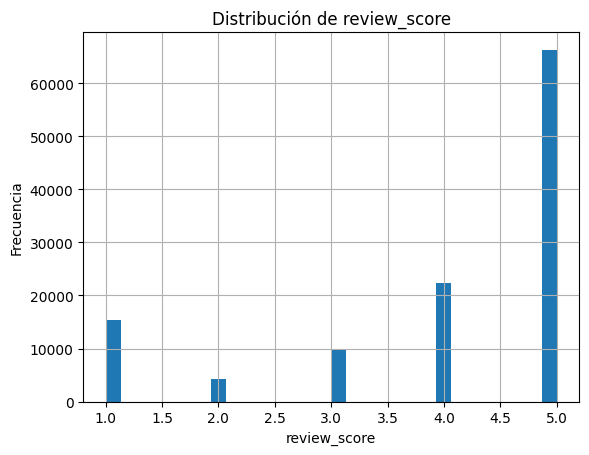

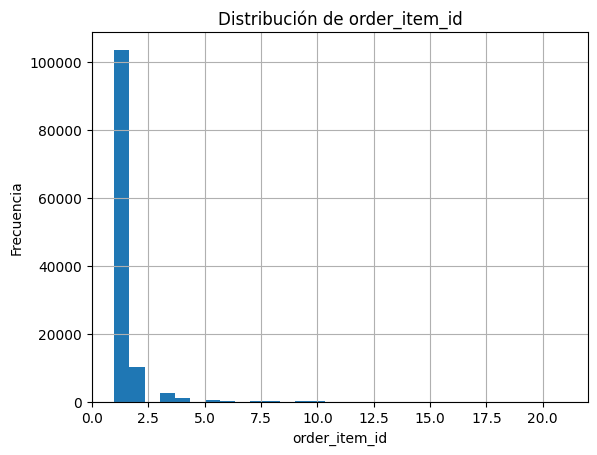

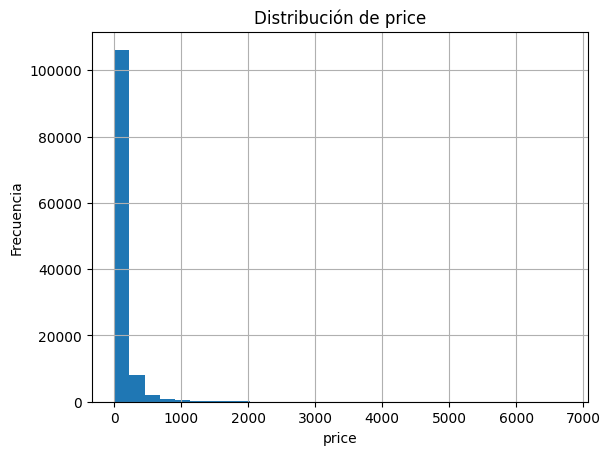

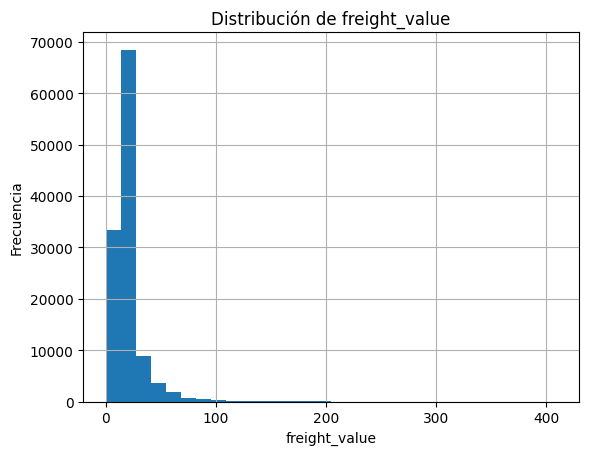

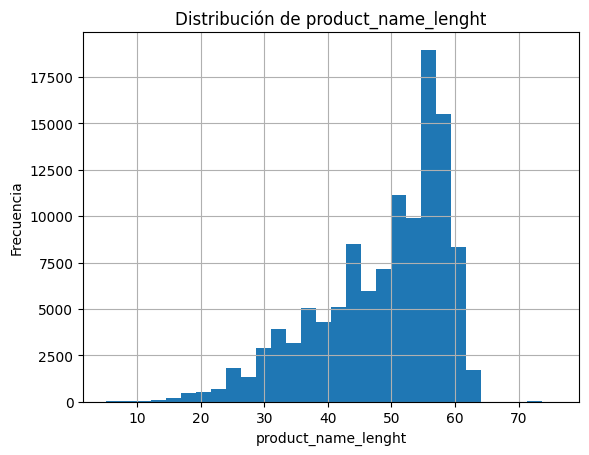

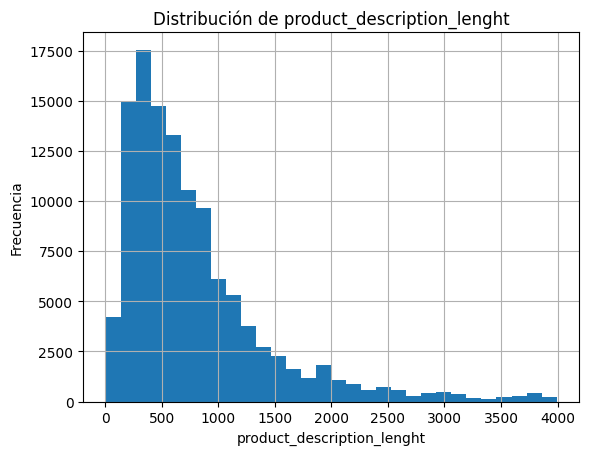

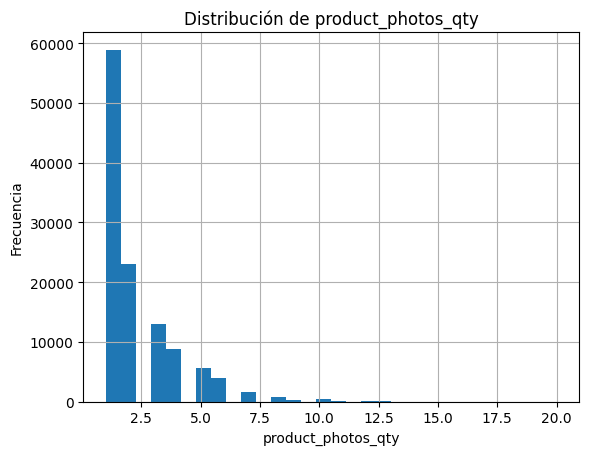

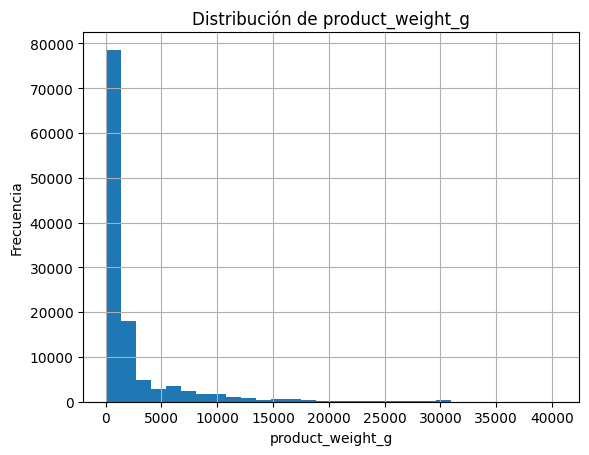

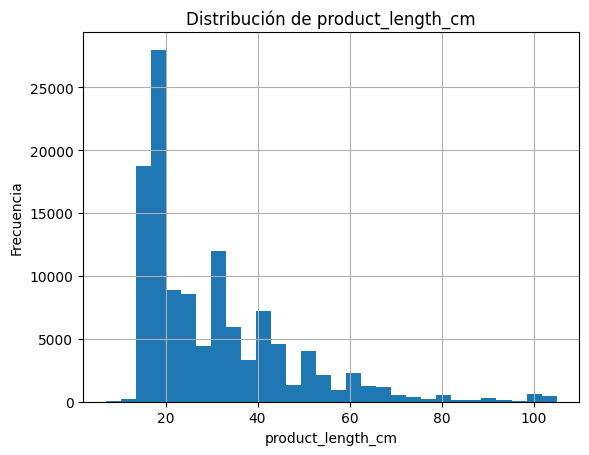

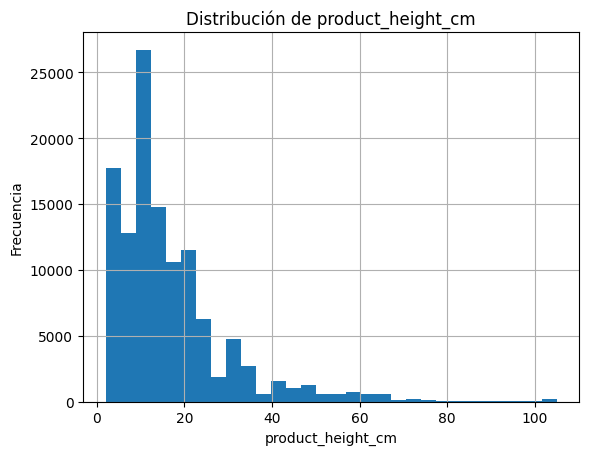

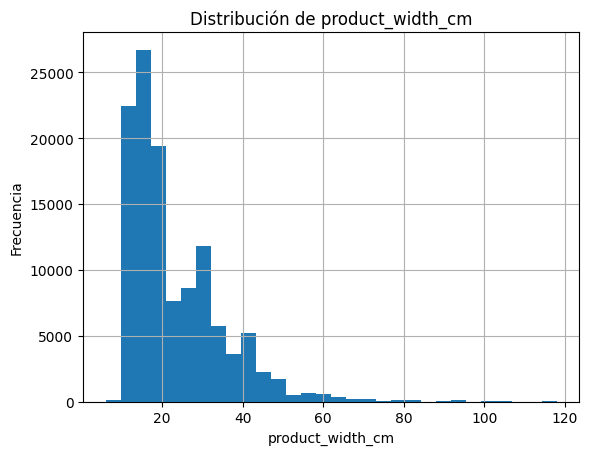

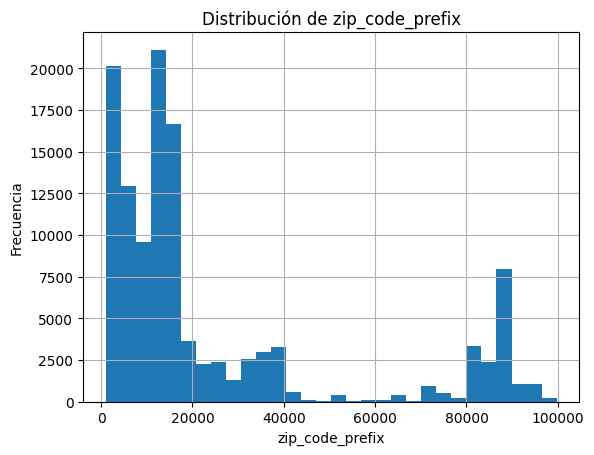

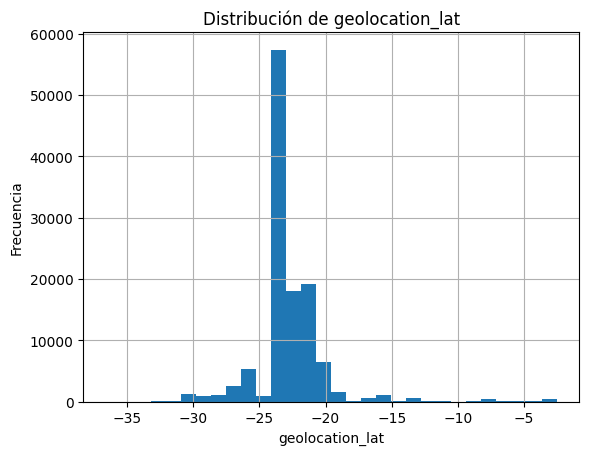

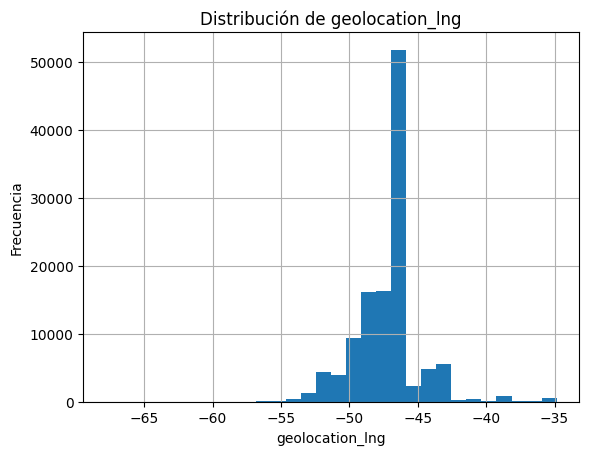

In [8]:
# Histogramas
for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()
# Lista de variables categóricas que quieras graficar
cat_cols = [
    "order_status",
    "payment_type",
    "customer_state",
    "seller_state",
    "product_category_name_english"
]


order_status (niveles = 8):
 order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


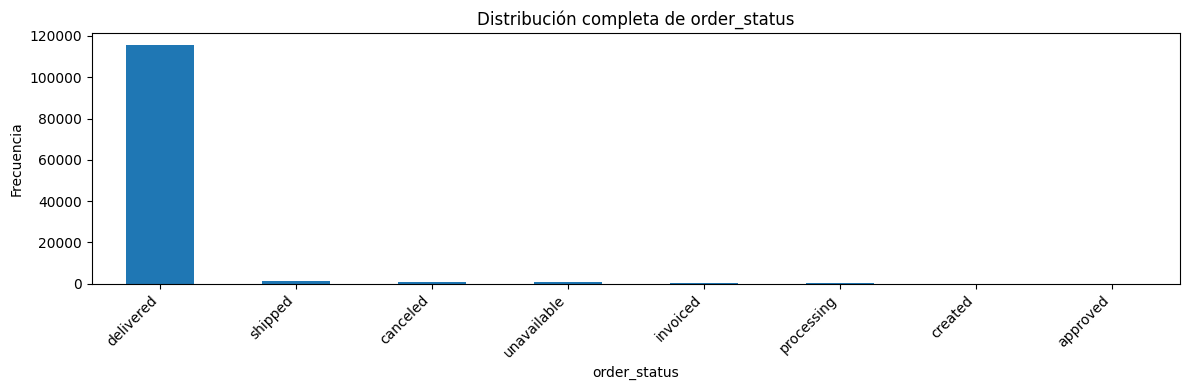


payment_type (niveles = 6):
 payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
NaN                3
Name: count, dtype: int64


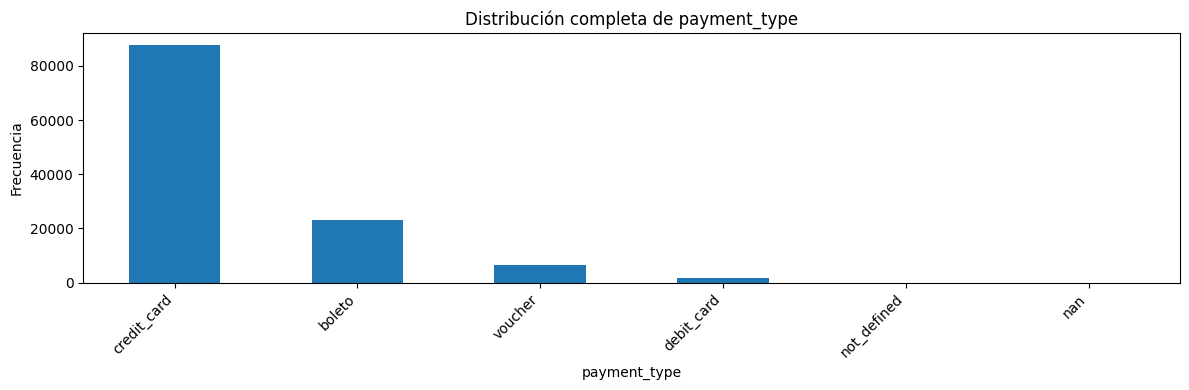


customer_state (niveles = 27):
 customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
PE     1906
CE     1565
MT     1132
PA     1129
MS      862
MA      856
PB      644
PI      576
RN      574
AL      464
SE      403
TO      340
RO      292
AM      173
AC       95
AP       84
RR       52
Name: count, dtype: int64


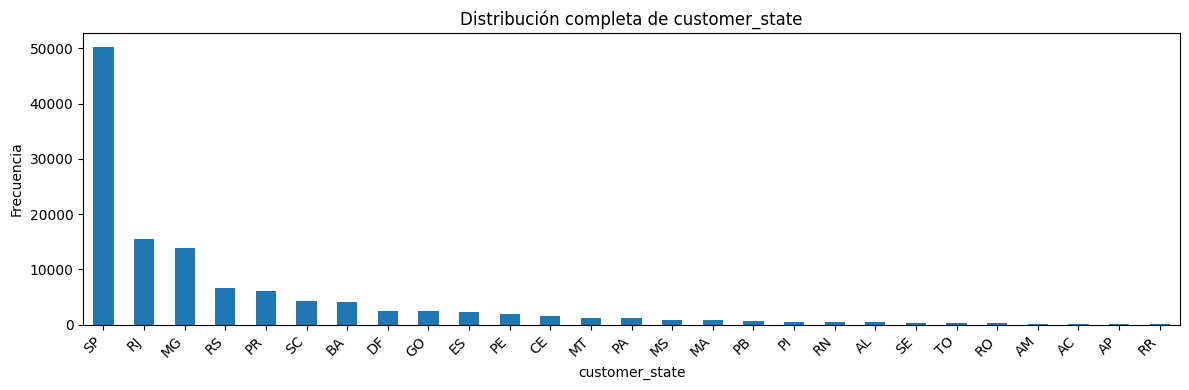


seller_state (niveles = 24):
 seller_state
SP     84377
MG      9314
PR      9096
RJ      5036
SC      4271
RS      2294
DF       949
NaN      833
BA       700
GO       550
PE       465
MA       410
ES       390
MT       147
CE       103
MS        60
RN        56
PB        44
RO        14
PI        12
SE        10
PA         8
AM         3
AC         1
Name: count, dtype: int64


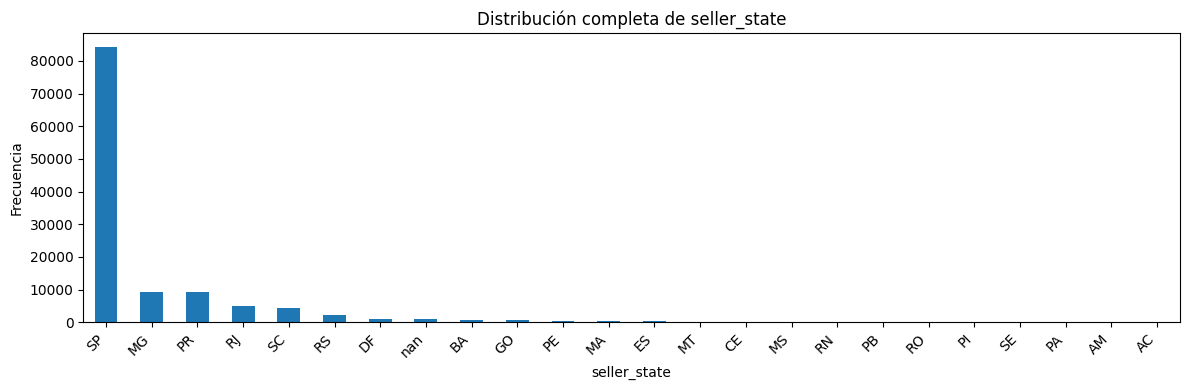


product_category_name_english (niveles = 72):
 product_category_name_english
bed_bath_table               11988
health_beauty                10032
sports_leisure                9004
furniture_decor               8832
computers_accessories         8150
                             ...  
arts_and_craftmanship           24
la_cuisine                      16
cds_dvds_musicals               14
fashion_childrens_clothes        8
security_and_services            2
Name: count, Length: 72, dtype: int64


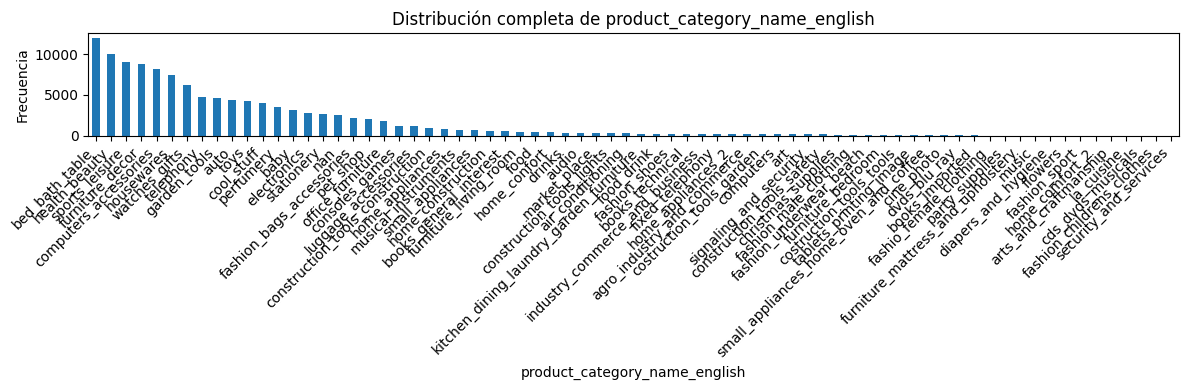

In [8]:
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    print(f"\n{col} (niveles = {counts.shape[0]}):\n", counts)
    
    plt.figure(figsize=(12, 4))
    counts.plot.bar()
    plt.title(f"Distribución completa de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

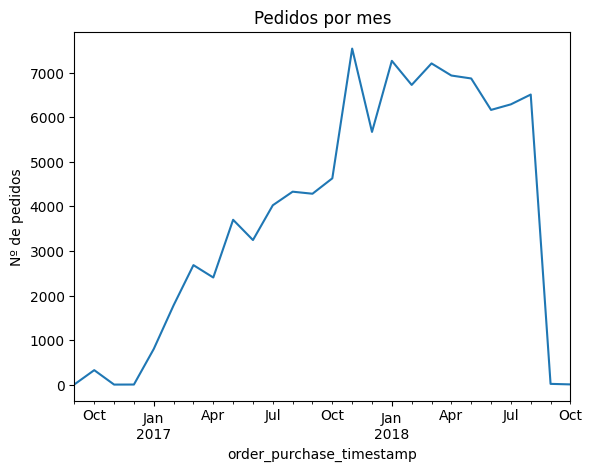

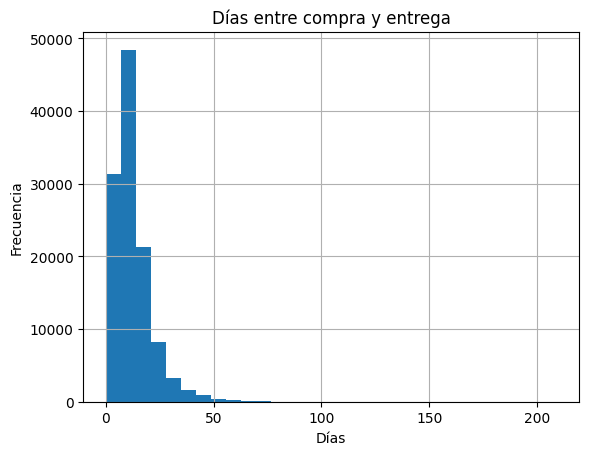

In [9]:
# 3.1 Pedidos por mes
series = df.set_index("order_purchase_timestamp")["order_id"]
pedidos_mes = series.resample("M").nunique()

plt.figure()
pedidos_mes.plot()
plt.title("Pedidos por mes")
plt.ylabel("Nº de pedidos")
plt.show()

# 3.2 Tiempos de entrega
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

plt.figure()
df["delivery_time_days"].hist(bins=30)
plt.title("Días entre compra y entrega")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.show()

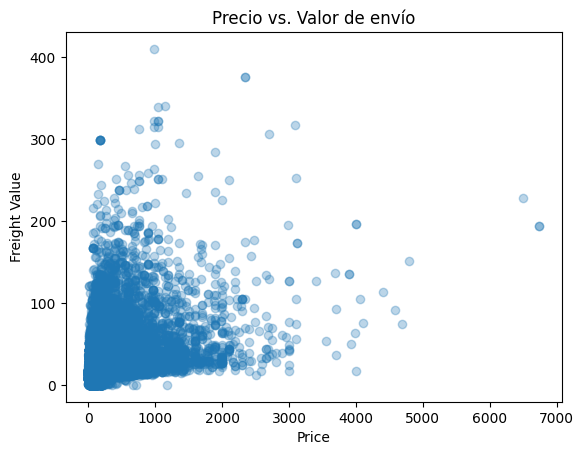

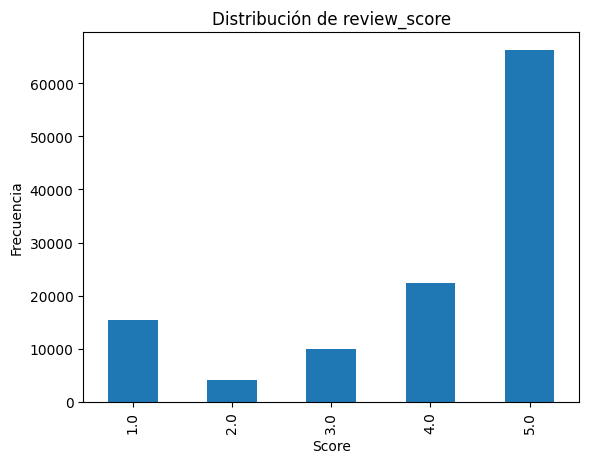

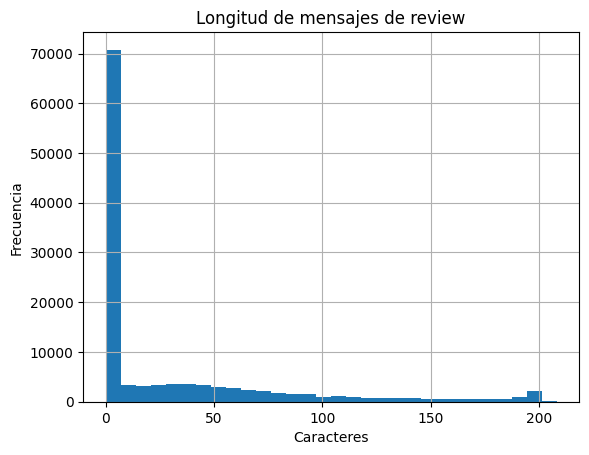

In [10]:
# 4.1 Relación precio vs. freight_value
plt.figure()
plt.scatter(df["price"], df["freight_value"], alpha=0.3)
plt.title("Precio vs. Valor de envío")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.show()

plt.figure()
df["review_score"].value_counts().sort_index().plot.bar()
plt.title("Distribución de review_score")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

df["msg_len"] = df["review_comment_message"].fillna("").str.len()
plt.figure()
df["msg_len"].hist(bins=30)
plt.title("Longitud de mensajes de review")
plt.xlabel("Caracteres")
plt.ylabel("Frecuencia")
plt.show()

payment_value                 1.000000
price                         0.739236
freight_value                 0.373762
product_weight_g              0.303326
payment_installments          0.273647
order_item_id                 0.265217
product_height_cm             0.217155
product_description_lenght    0.156108
product_width_cm              0.148606
product_length_cm             0.138755
zip_code_prefix               0.069818
msg_len                       0.064852
delivery_time_days            0.060449
customer_zip_code_prefix      0.054519
geolocation_lng               0.029426
geolocation_lat               0.012744
product_photos_qty            0.010075
product_name_lenght           0.002371
payment_sequential           -0.064467
review_score                 -0.082343
Name: payment_value, dtype: float64


C:\Users\fdcontreras\AppData\Local\Temp\ipykernel_1944\622600155.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


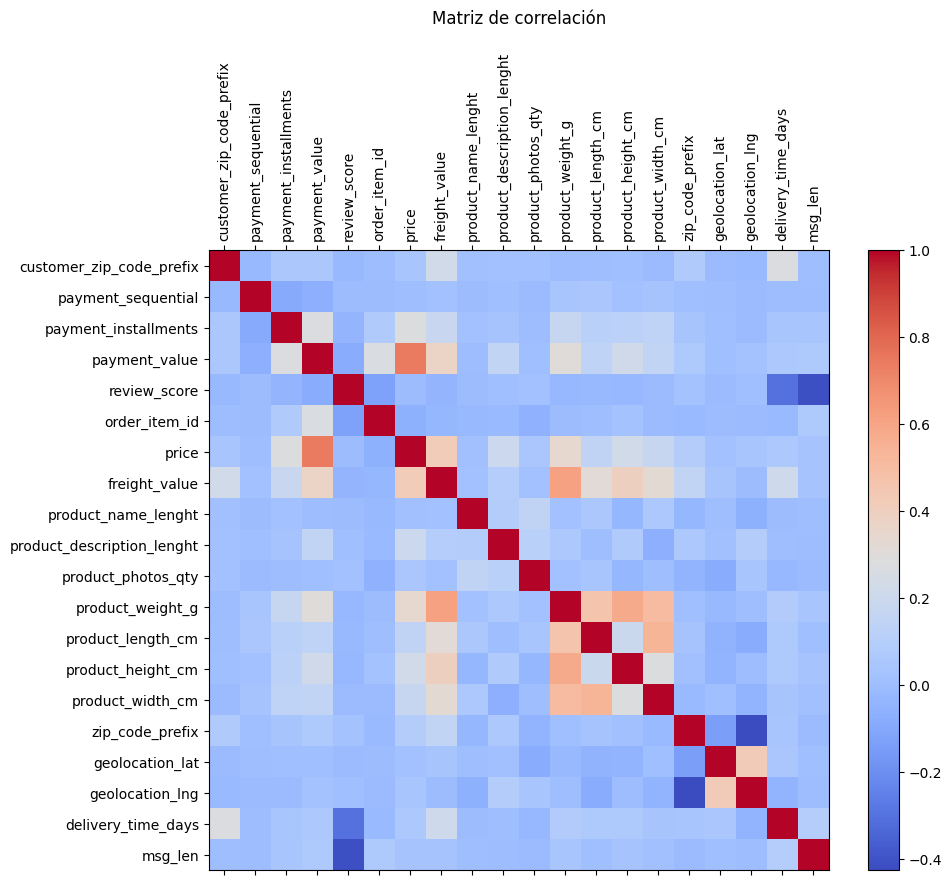

In [11]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

corr = df[num_cols].corr()

print(corr["payment_value"].sort_values(ascending=False))

plt.figure(figsize=(10,8))
plt.matshow(corr, cmap="coolwarm", fignum=1)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Matriz de correlación", pad=20)
plt.tight_layout()
plt.show()

In [11]:
%pip install statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

C:\Users\fdcontreras\AppData\Local\Temp\ipykernel_1944\1580501123.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


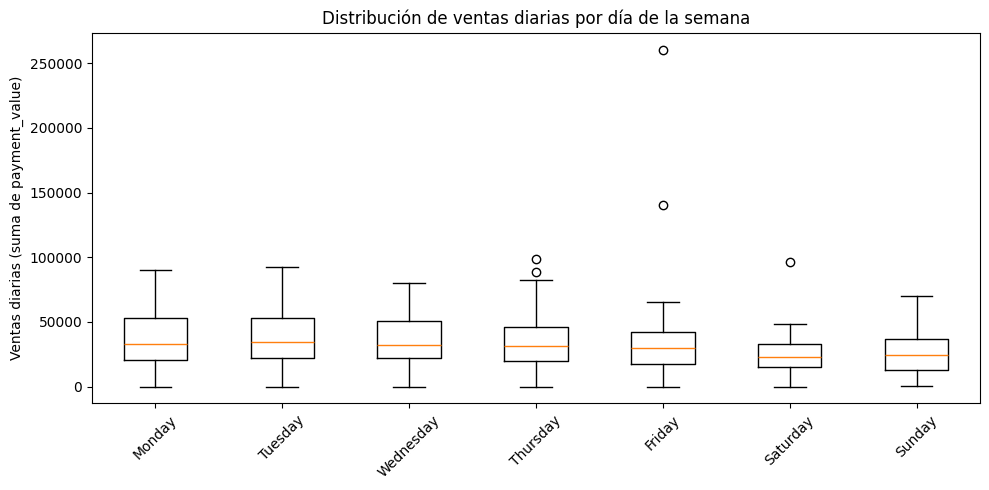

In [12]:
df["date"] = df["order_purchase_timestamp"].dt.date

df["date"] = df["order_purchase_timestamp"].dt.date
daily_sales = (
    df
    .groupby("date")["payment_value"]
    .sum()
    .rename("sales")
    .reset_index()
)
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

# 2. Extraer día de la semana y mes
daily_sales["dow"]   = daily_sales["date"].dt.day_name()
daily_sales["month"] = daily_sales["date"].dt.month

#3. Boxplot de ventas por día de la semana
plt.figure(figsize=(10, 5))
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
data  = [daily_sales.loc[daily_sales["dow"]==d, "sales"] for d in order]
plt.boxplot(data, labels=order)
plt.title("Distribución de ventas diarias por día de la semana")
plt.ylabel("Ventas diarias (suma de payment_value)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

        date     sales        dow  month
0 2016-09-04    272.46     Sunday      9
1 2016-09-05     75.06     Monday      9
2 2016-09-13     40.95    Tuesday      9
3 2016-09-15      0.00   Thursday      9
4 2016-10-02    109.34     Sunday     10
5 2016-10-03    595.14     Monday     10
6 2016-10-04  14075.31    Tuesday     10
7 2016-10-05  16319.57  Wednesday     10
8 2016-10-06  11645.27   Thursday     10
9 2016-10-07  10492.23     Friday     10
          date   sales        dow  month
629 2018-09-29  137.03   Saturday      9
630 2018-10-01   80.38     Monday     10
631 2018-10-03  197.55  Wednesday     10
632 2018-10-16  222.03    Tuesday     10
633 2018-10-17   89.71  Wednesday     10
          date     sales     dow  month
320 2017-11-06  41271.04  Monday     11
327 2017-11-13  37286.16  Monday     11
334 2017-11-20  62994.29  Monday     11
341 2017-11-27  81093.07  Monday     11


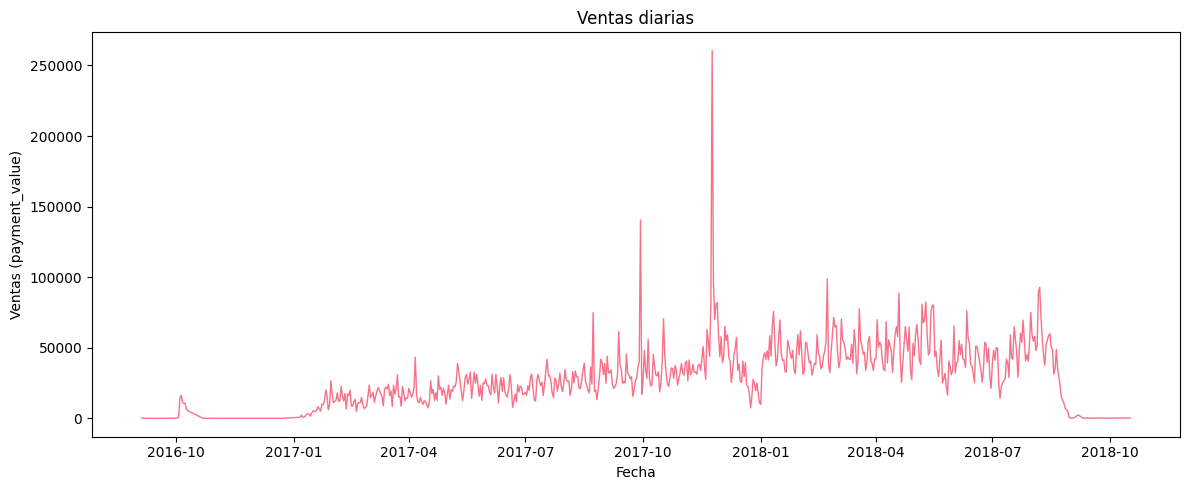

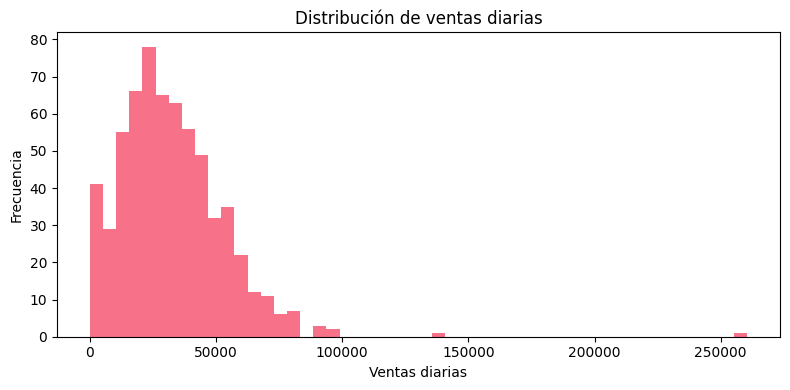

In [62]:
df["date"] = df["order_purchase_timestamp"].dt.floor("d")

daily_sales = (
    df
    .groupby("date")["payment_value"]
    .sum()
    .reset_index(name="sales")
)

daily_sales["dow"]   = daily_sales["date"].dt.day_name()
daily_sales["month"] = daily_sales["date"].dt.month

print(daily_sales.head(10))    
print(daily_sales.tail(5))     

filt = daily_sales.query('dow == "Monday" and month == 11')
print(filt)

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["sales"], linewidth=1)
plt.title("Ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas (payment_value)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(daily_sales["sales"], bins=50)
plt.title("Distribución de ventas diarias")
plt.xlabel("Ventas diarias")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# EDA Variable objetivo

In [60]:
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, shapiro
import warnings
warnings.filterwarnings('ignore')


1. 📊 ANÁLISIS DE LA VARIABLE OBJETIVO
--------------------------------------------------
Estadísticas descriptivas de payment_value:
count    119140.000000
mean        172.735135
std         267.776077
min           0.000000
25%          60.850000
50%         108.160000
75%         189.240000
max       13664.080000
Name: payment_value, dtype: float64

Información adicional:
• Valores únicos: 29,077
• Valores faltantes: 3
• Valores cero: 9
• Valores negativos: 0


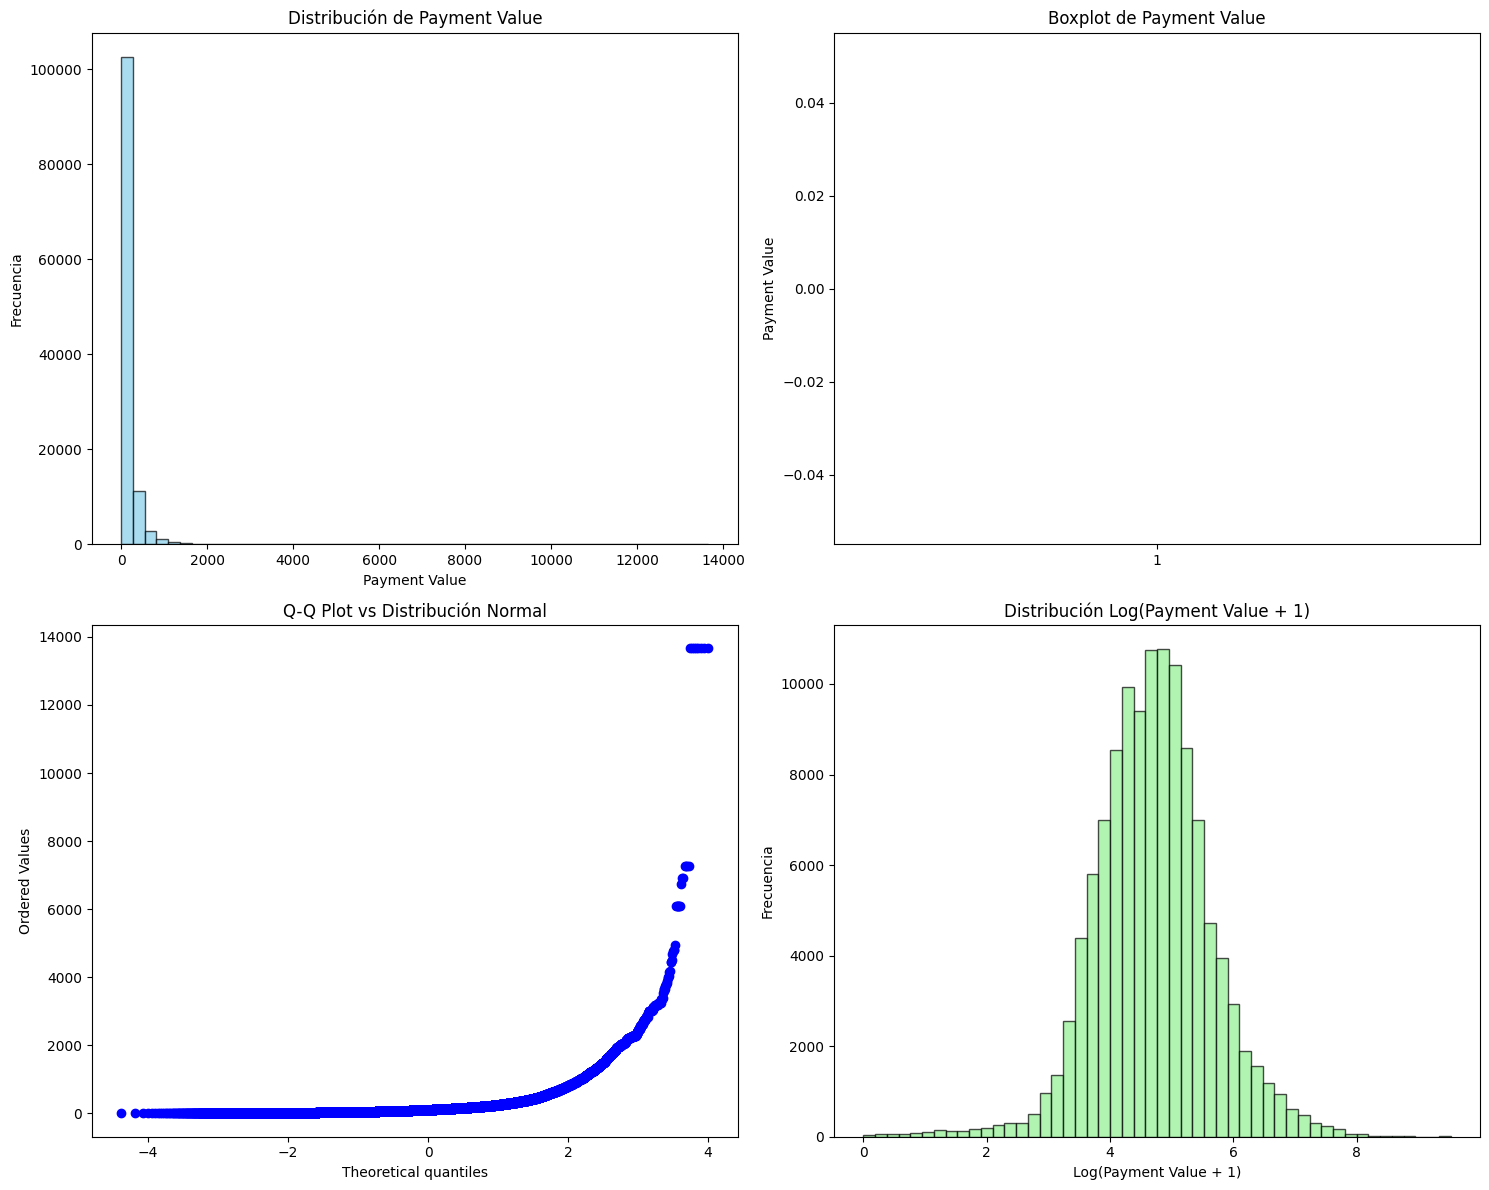

In [61]:
# 1. ANÁLISIS DE LA VARIABLE OBJETIVO (payment_value)
print("\n1. 📊 ANÁLISIS DE LA VARIABLE OBJETIVO")
print("-"*50)

# Estadísticas descriptivas
print("Estadísticas descriptivas de payment_value:")
print(df['payment_value'].describe())

# Información adicional
print(f"\nInformación adicional:")
print(f"• Valores únicos: {df['payment_value'].nunique():,}")
print(f"• Valores faltantes: {df['payment_value'].isnull().sum():,}")
print(f"• Valores cero: {(df['payment_value'] == 0).sum():,}")
print(f"• Valores negativos: {(df['payment_value'] < 0).sum():,}")

# Gráficos de distribución
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histograma
axes[0,0].hist(df['payment_value'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución de Payment Value')
axes[0,0].set_xlabel('Payment Value')
axes[0,0].set_ylabel('Frecuencia')

# Boxplot
axes[0,1].boxplot(df['payment_value'])
axes[0,1].set_title('Boxplot de Payment Value')
axes[0,1].set_ylabel('Payment Value')

# Q-Q Plot
stats.probplot(df['payment_value'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot vs Distribución Normal')

# Log transformation
payment_log = np.log1p(df['payment_value'])
axes[1,1].hist(payment_log, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,1].set_title('Distribución Log(Payment Value + 1)')
axes[1,1].set_xlabel('Log(Payment Value + 1)')
axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [63]:
# Tests de normalidad
print(f"\n📈 Tests de Normalidad:")
jb_stat, jb_pvalue = jarque_bera(df['payment_value'].dropna())
print(f"• Jarque-Bera Test: estadístico={jb_stat:.4f}, p-value={jb_pvalue:.6f}")

if len(df) <= 5000:  # Shapiro-Wilk solo para muestras pequeñas
    sw_stat, sw_pvalue = shapiro(df['payment_value'].sample(5000).dropna())
    print(f"• Shapiro-Wilk Test: estadístico={sw_stat:.4f}, p-value={sw_pvalue:.6f}")


📈 Tests de Normalidad:
• Jarque-Bera Test: estadístico=1246613643.8776, p-value=0.000000


In [64]:
# 2. ANÁLISIS DE OUTLIERS
print("\n\n2. 🎯 ANÁLISIS DE OUTLIERS")
print("-"*50)

Q1 = df['payment_value'].quantile(0.25)
Q3 = df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df['payment_value'] < lower_bound) | 
                  (df['payment_value'] > upper_bound)).sum()

print(f"Rango intercuartílico (IQR): {IQR:.2f}")
print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")
print(f"Número de outliers: {outliers_count:,} ({outliers_count/len(df)*100:.2f}%)")

# Percentiles extremos
print(f"\nPercentiles extremos:")
for p in [99, 99.5, 99.9, 99.95, 99.99]:
    value = df['payment_value'].quantile(p/100)
    print(f"• Percentil {p}%: {value:.2f}")



2. 🎯 ANÁLISIS DE OUTLIERS
--------------------------------------------------
Rango intercuartílico (IQR): 128.39
Límite inferior: -131.74
Límite superior: 381.83
Número de outliers: 9,638 (8.09%)

Percentiles extremos:
• Percentil 99%: 1222.89
• Percentil 99.5%: 1643.86
• Percentil 99.9%: 2729.46
• Percentil 99.95%: 3195.73
• Percentil 99.99%: 6959.06




3. 📅 ANÁLISIS TEMPORAL
--------------------------------------------------
Estadísticas mensuales de payment_value:
         count    mean  median     std    min      max
date                                                  
2016-09      4   97.12  105.64   47.26  40.95   136.23
2016-10    401  190.92  117.48  204.15   0.74  1423.55
2016-12      1   19.62   19.62     NaN  19.62    19.62
2017-01   1035  184.35  110.70  239.67   0.96  3016.01
2017-02   2123  165.73  106.17  271.62   0.28  6929.31
2017-03   3243  168.91  103.68  250.64   0.13  4016.91
2017-04   2878  177.95  103.59  294.78   0.00  4950.34
2017-05   4485  164.42  103.37  248.26   0.00  6726.66
2017-06   3853  159.30  100.00  234.20   0.00  3048.27
2017-07   4949  151.39  100.34  180.59   0.20  3041.73


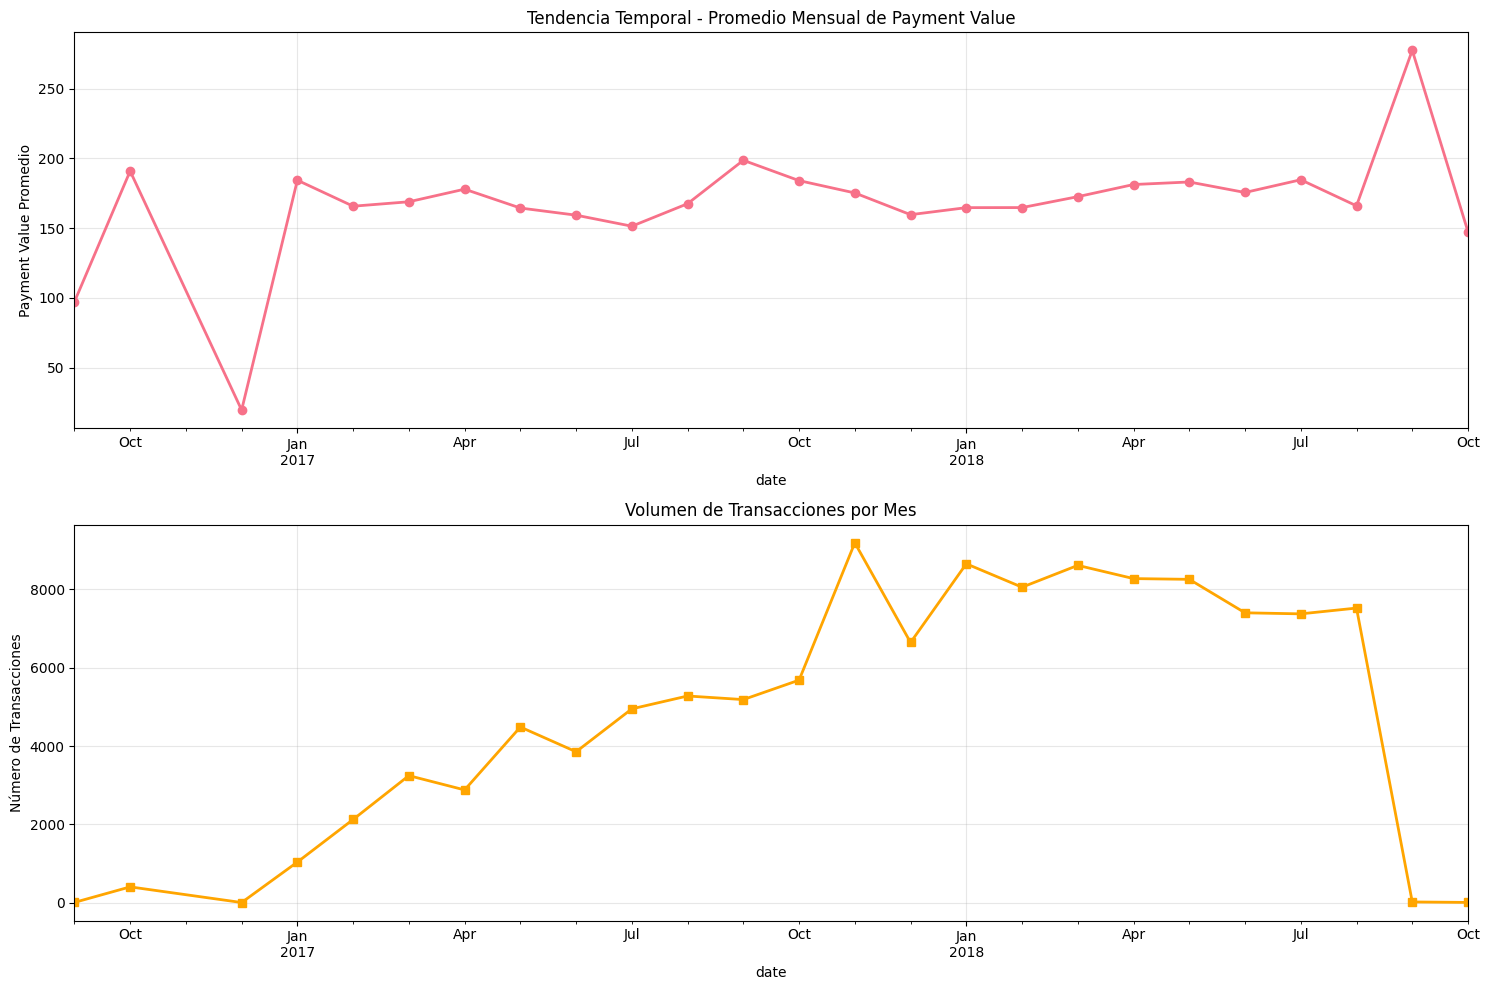

In [65]:
# 3. ANÁLISIS TEMPORAL
print("\n\n3. 📅 ANÁLISIS TEMPORAL")
print("-"*50)

# Verificar si existe columna de fecha
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    
    # Estadísticas por período
    monthly_stats = df.groupby(df['date'].dt.to_period('M'))['payment_value'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    
    print("Estadísticas mensuales de payment_value:")
    print(monthly_stats.head(10))
    
    # Gráfico temporal
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Tendencia temporal - promedio mensual
    monthly_avg = df.groupby(df['date'].dt.to_period('M'))['payment_value'].mean()
    monthly_avg.plot(ax=axes[0], marker='o', linewidth=2)
    axes[0].set_title('Tendencia Temporal - Promedio Mensual de Payment Value')
    axes[0].set_ylabel('Payment Value Promedio')
    axes[0].grid(True, alpha=0.3)
    
    # Volumen de transacciones
    monthly_count = df.groupby(df['date'].dt.to_period('M'))['payment_value'].count()
    monthly_count.plot(ax=axes[1], marker='s', color='orange', linewidth=2)
    axes[1].set_title('Volumen de Transacciones por Mes')
    axes[1].set_ylabel('Número de Transacciones')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No se encontró columna 'date' para análisis temporal")



4. 🔗 ANÁLISIS DE CORRELACIONES
--------------------------------------------------
Columnas numéricas encontradas: 41

Correlaciones con payment_value (Top 10):
y                       1.000000
payment_value           1.000000
price                   0.739236
y_log                   0.676659
lag_1                   0.431519
freight_value           0.373762
roll_mean_7             0.317705
product_weight_g        0.303326
payment_installments    0.273647
order_item_id           0.265217
Name: payment_value, dtype: float64


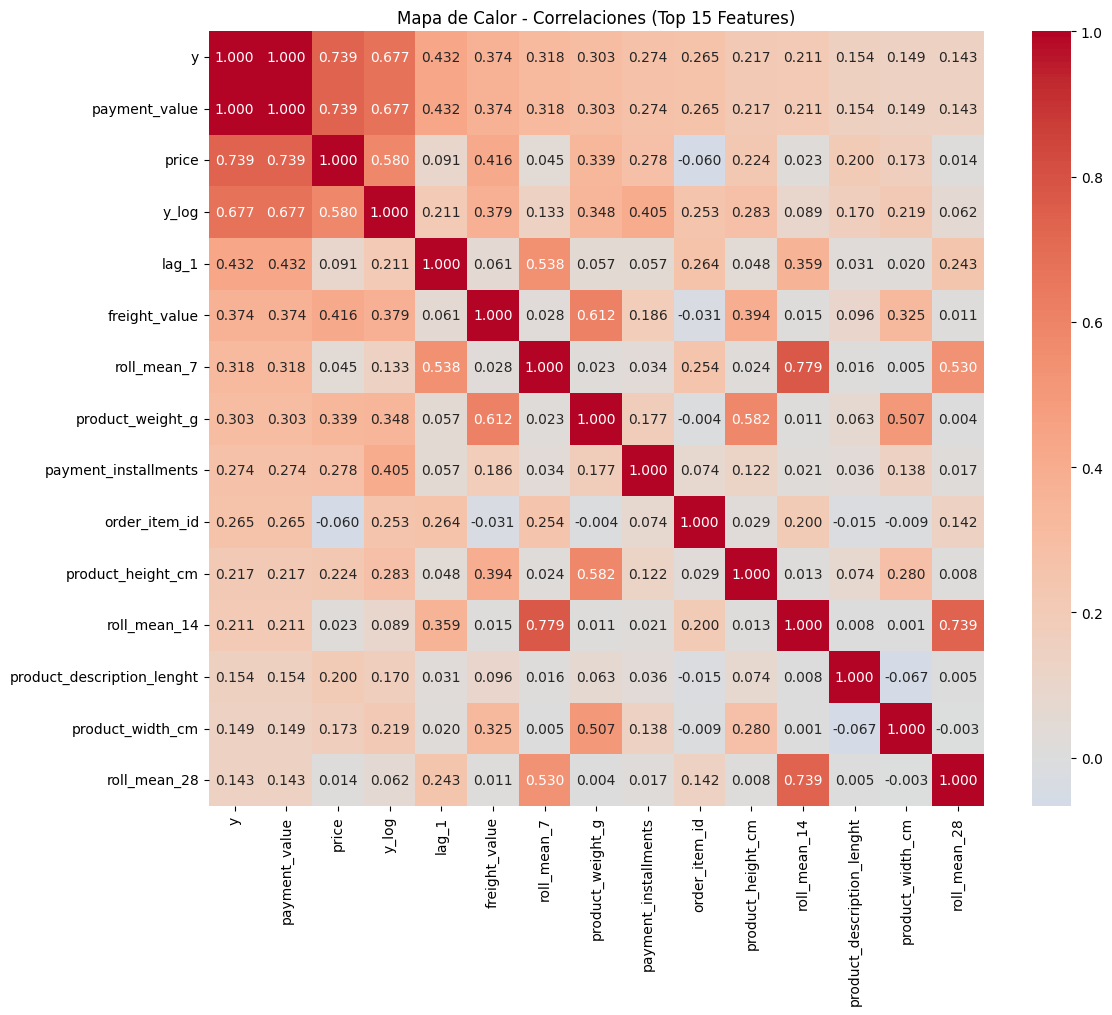


🔍 Análisis de Multicolinealidad:
Pares con alta correlación (>0.8):
• payment_value - y: 1.000
• status_delivered - status_delivered: 1.000
• status_shipped - status_shipped: 1.000


In [66]:
# 4. ANÁLISIS DE CORRELACIONES
print("\n\n4. 🔗 ANÁLISIS DE CORRELACIONES")
print("-"*50)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas encontradas: {len(numeric_cols)}")

if len(numeric_cols) > 1:
    # Matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Correlaciones con payment_value
    corr_with_target = correlation_matrix['payment_value'].sort_values(ascending=False)
    print(f"\nCorrelaciones con payment_value (Top 10):")
    print(corr_with_target.head(10))
    
    # Heatmap de correlaciones (solo top variables)
    top_corr_features = corr_with_target.head(15).index.tolist()
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[top_corr_features].corr(), 
                annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f')
    plt.title('Mapa de Calor - Correlaciones (Top 15 Features)')
    plt.tight_layout()
    plt.show()
    
    # Identificar multicolinealidad
    print(f"\n🔍 Análisis de Multicolinealidad:")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.8:  # Umbral de alta correlación
                high_corr_pairs.append((
                    correlation_matrix.columns[i], 
                    correlation_matrix.columns[j], 
                    corr_val
                ))
    
    if high_corr_pairs:
        print("Pares con alta correlación (>0.8):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"• {feat1} - {feat2}: {corr:.3f}")
    else:
        print("• No se encontraron correlaciones muy altas (>0.8)")

In [67]:
# 5. ANÁLISIS DE FEATURES CATEGÓRICAS
print("\n\n5. 📊 ANÁLISIS DE FEATURES CATEGÓRICAS")
print("-"*50)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Columnas categóricas encontradas: {len(categorical_cols)}")

for col in categorical_cols[:5]:  # Solo las primeras 5
    unique_vals = df[col].nunique()
    print(f"\n• {col}:")
    print(f"  - Valores únicos: {unique_vals}")
    print(f"  - Valores faltantes: {df[col].isnull().sum()}")
    
    if unique_vals <= 10:  # Solo si no hay demasiadas categorías
        print(f"  - Distribución:")
        value_counts = df[col].value_counts().head()
        for val, count in value_counts.items():
            print(f"    {val}: {count} ({count/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("              RESUMEN DEL ANÁLISIS")
print("="*60)
print("✅ Análisis de distribución de variable objetivo completado")
print("✅ Identificación de outliers realizada") 
print("✅ Análisis temporal ejecutado")
print("✅ Matriz de correlaciones generada")
print("✅ Análisis de variables categóricas finalizado")
print("\n💡 Revisa los gráficos y estadísticas para decidir:")
print("   • ¿Necesitas transformar la variable objetivo?")
print("   • ¿Hay outliers que manejar?")
print("   • ¿Existe multicolinealidad?")
print("   • ¿Las relaciones son lineales?")



5. 📊 ANÁLISIS DE FEATURES CATEGÓRICAS
--------------------------------------------------
Columnas categóricas encontradas: 19

• order_id:
  - Valores únicos: 99441
  - Valores faltantes: 0

• customer_id:
  - Valores únicos: 99441
  - Valores faltantes: 0

• order_status:
  - Valores únicos: 8
  - Valores faltantes: 0
  - Distribución:
    delivered: 115723 (97.1%)
    shipped: 1256 (1.1%)
    canceled: 750 (0.6%)
    unavailable: 652 (0.5%)
    invoiced: 378 (0.3%)

• customer_unique_id:
  - Valores únicos: 96096
  - Valores faltantes: 0

• customer_city:
  - Valores únicos: 4119
  - Valores faltantes: 0

              RESUMEN DEL ANÁLISIS
✅ Análisis de distribución de variable objetivo completado
✅ Identificación de outliers realizada
✅ Análisis temporal ejecutado
✅ Matriz de correlaciones generada
✅ Análisis de variables categóricas finalizado

💡 Revisa los gráficos y estadísticas para decidir:
   • ¿Necesitas transformar la variable objetivo?
   • ¿Hay outliers que manejar?
   •

In [14]:
# 1) Lista de features con |r| ≥ 0.10
features = [
    "price",
    "freight_value",
    "product_weight_g",
    "payment_installments",
    "order_item_id",
    "product_height_cm",
    "product_description_lenght",
    "product_width_cm",
    "product_length_cm"
]

# 2) Ver % de nulos en cada una
null_pct = df[features].isnull().mean() * 100
print(null_pct.sort_values(ascending=False))

product_description_lenght    2.133571
product_weight_g              0.715946
product_height_cm             0.715946
product_width_cm              0.715946
product_length_cm             0.715946
price                         0.699160
freight_value                 0.699160
order_item_id                 0.699160
payment_installments          0.002518
dtype: float64


In [15]:
# Lista de tus features finales
features = [
    "price",
    "freight_value",
    "product_weight_g",
    "payment_installments",
    "order_item_id",
    "product_height_cm",
    "product_description_lenght",
    "product_width_cm",
    "product_length_cm",
]

# Imputar con mediana manualmente
for col in ["product_description_lenght", "payment_installments"]:
    med = df[col].median()
    df[col].fillna(med, inplace=True)

# Verificar que ya no queden nulos
print(df[features].isnull().mean() * 100)


price                         0.699160
freight_value                 0.699160
product_weight_g              0.715946
payment_installments          0.000000
order_item_id                 0.699160
product_height_cm             0.715946
product_description_lenght    0.000000
product_width_cm              0.715946
product_length_cm             0.715946
dtype: float64


In [17]:
!pip install prince
import prince

  Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl (11.5 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.1.4
    Uninstalling pandas-2.1.4:
      Successfully uninstalled pandas-2.1.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pycaret 3.3.2 requires matplotlib<3.8.0, but you have matplotlib 3.10.3 which is incompatible.
pycaret 3.3.2 requires pandas<2.2.0, but you have pandas 2.2.3 which is incompatible.
sktime 0.26.0 requires pandas<2.2.0,>=1.1, but you have pandas 2.2.3 which is incompatible.
sktime 0.26.0 requires scikit-learn<1.5.0,>=0.24, but you have scikit-learn 1.5.2 which is incompatible.
ydata-profiling 4.16.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.3 which is incompatible.


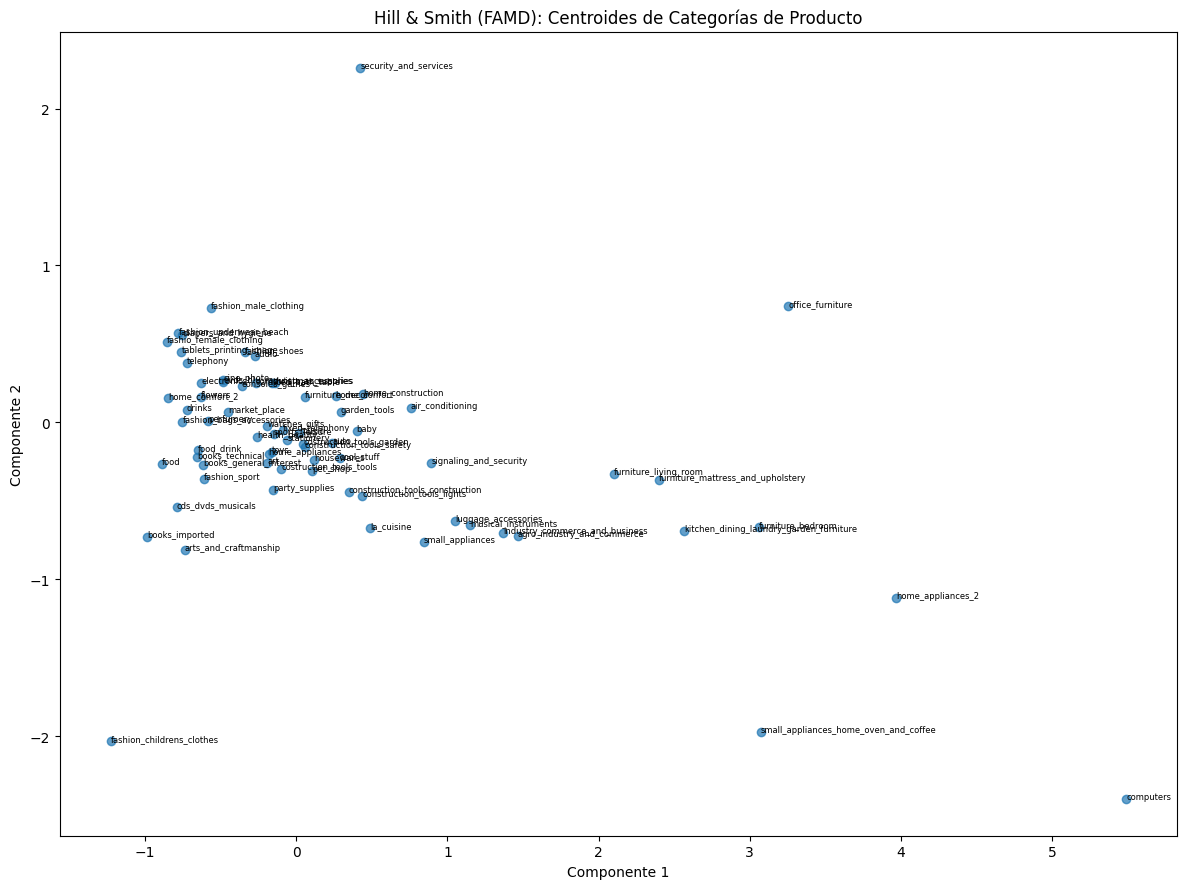

In [18]:
num_vars = [
    "price",
    "freight_value",
    "product_weight_g",
    "delivery_time_days",
    "review_score"
]

cat_var = "product_category_name_english"

# 2. Crea un DataFrame con filas limpias y solo esas columnas
df_mixed = df[num_vars + [cat_var]].dropna()

# 3. Aplica FAMD (Hill & Smith) para 2 componentes
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    random_state=42
).fit(df_mixed)

# 4. Obtén las coordenadas de cada fila (pedido)
coords = famd.row_coordinates(df_mixed)

# 5. Calcula el centroide de cada categoría
centroids = coords.join(df_mixed[[cat_var]]).groupby(cat_var).mean()

# 6. Dibuja los centroides en el espacio factorial
plt.figure(figsize=(12, 9))
plt.scatter(centroids[0], centroids[1], alpha=0.7)

for label, (x, y) in centroids.iterrows():
    plt.text(x, y, label, fontsize=6)

plt.title("Hill & Smith (FAMD): Centroides de Categorías de Producto")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.tight_layout()
plt.show()

c:\Users\fdcontreras\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


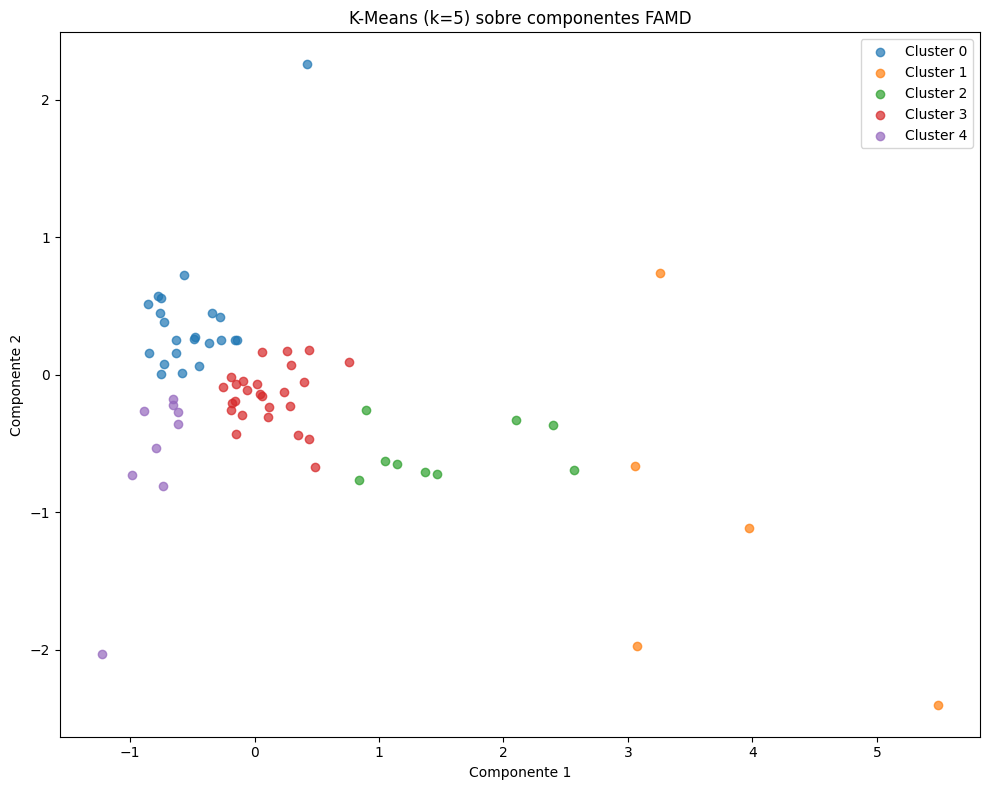


Cluster 0 (22 categorías):
 ['audio', 'bed_bath_table', 'christmas_supplies', 'cine_photo', 'computers_accessories', 'consoles_games', 'diapers_and_hygiene', 'drinks', 'dvds_blu_ray', 'electronics', 'fashio_female_clothing', 'fashion_bags_accessories', 'fashion_male_clothing', 'fashion_shoes', 'fashion_underwear_beach', 'flowers', 'home_comfort_2', 'market_place', 'perfumery', 'security_and_services', 'tablets_printing_image', 'telephony']

Cluster 1 (5 categorías):
 ['computers', 'furniture_bedroom', 'home_appliances_2', 'office_furniture', 'small_appliances_home_oven_and_coffee']

Cluster 2 (9 categorías):
 ['agro_industry_and_commerce', 'furniture_living_room', 'furniture_mattress_and_upholstery', 'industry_commerce_and_business', 'kitchen_dining_laundry_garden_furniture', 'luggage_accessories', 'musical_instruments', 'signaling_and_security', 'small_appliances']

Cluster 3 (26 categorías):
 ['air_conditioning', 'art', 'auto', 'baby', 'construction_tools_construction', 'constructio

In [19]:
from sklearn.cluster import KMeans

# 'centroids' es tu DataFrame indexado por categoría con columnas [0,1]
X = centroids.values

# 1.1 Elige número de clusters (p. ej. k=4). Puedes usar el método del codo para ajustarlo.
k = 5
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)

# 1.2 Añade la etiqueta de cluster a tu DataFrame de centroides
centroids["cluster"] = kmeans.labels_

# 1.3 Scatter coloreado por cluster
plt.figure(figsize=(10, 8))
for c in range(k):
    sub = centroids[centroids["cluster"] == c]
    plt.scatter(sub[0], sub[1], label=f"Cluster {c}", alpha=0.7)
plt.legend()
plt.title(f"K-Means (k={k}) sobre componentes FAMD")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.tight_layout()
plt.show()

# 1.4 Ver qué categorías hay en cada cluster
for c in range(k):
    cats = centroids[centroids["cluster"] == c].index.tolist()
    print(f"\nCluster {c} ({len(cats)} categorías):\n", cats)


In [20]:
# 1.1 Mapeo categoría → cluster
cat_to_cluster = {cat: c for c, cats in centroids.groupby("cluster").groups.items() for cat in cats}

# 1.2 Añadir columna cluster a cada pedido
df["cluster"] = df["product_category_name_english"].map(cat_to_cluster).fillna(-1).astype(int)

# 1.3 Agregar métricas por cluster
perf = (
    df
    .groupby("cluster")["payment_value"]
    .agg(
        total_sales  = "sum",
        avg_sales    = "mean",
        num_orders   = "count"
    )
    .sort_values("avg_sales", ascending=False)
)
print(perf)


         total_sales   avg_sales  num_orders
cluster                                     
 1        1139144.72  458.962417        2482
 2        1108794.73  265.008301        4184
 3       12414753.58  174.264168       71241
-1         423058.87  164.806728        2567
 0        5315623.23  144.160313       36873
 4         178288.88   99.436074        1793


In [21]:
best_cluster = perf["avg_sales"].idxmax()
cats_best = centroids[centroids["cluster"] == best_cluster].index.tolist()

print(f"Cluster {best_cluster} es el mejor perfil según avg_sales.\nCategorías en él:\n", cats_best)


Cluster 1 es el mejor perfil según avg_sales.
Categorías en él:
 ['computers', 'furniture_bedroom', 'home_appliances_2', 'office_furniture', 'small_appliances_home_oven_and_coffee']


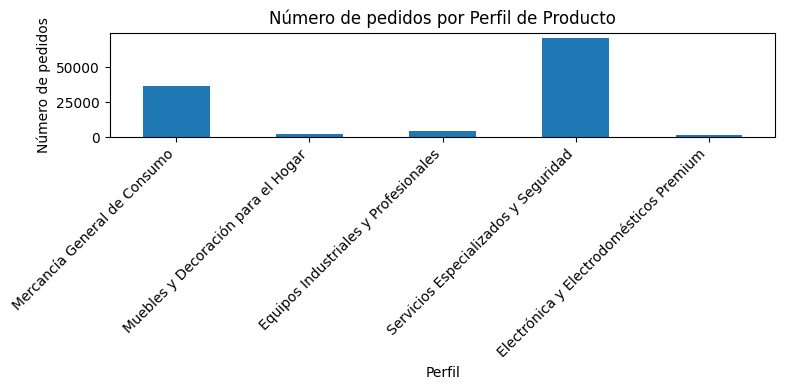

In [22]:
# 1. Define el mapeo de número de cluster → nombre
cluster_names = {
    0: "Mercancía General de Consumo",
    1: "Muebles y Decoración para el Hogar",
    2: "Equipos Industriales y Profesionales",
    3: "Servicios Especializados y Seguridad",
    4: "Electrónica y Electrodomésticos Premium"
}

# 2. Crea la columna con nombre del cluster
df["cluster_name"] = df["cluster"].map(cluster_names)

# 3. Distribución: número de pedidos por perfil
pedido_dist = df["cluster_name"].value_counts().reindex(cluster_names.values())

plt.figure(figsize=(8,4))
pedido_dist.plot.bar(color=None)
plt.title("Número de pedidos por Perfil de Producto")
plt.xlabel("Perfil")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

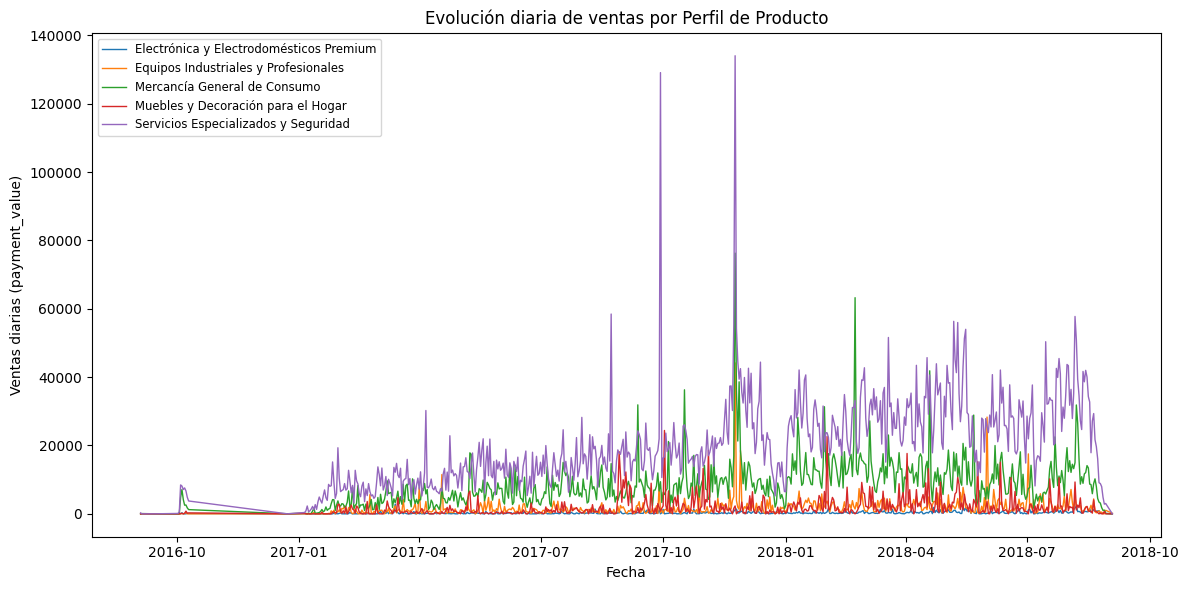

In [23]:
df["date"] = df["order_purchase_timestamp"].dt.floor("d")

# 2. Agrega las ventas diarias por perfil
ts = (
    df
    .groupby(["date","cluster_name"])["payment_value"]
    .sum()
    .unstack("cluster_name")
    .fillna(0)               # Si algún día falta un perfil, lo ponemos a 0
)

# 3. Plot de líneas
plt.figure(figsize=(12, 6))
for perfil in ts.columns:
    plt.plot(ts.index, ts[perfil], label=perfil, linewidth=1)

plt.title("Evolución diaria de ventas por Perfil de Producto")
plt.xlabel("Fecha")
plt.ylabel("Ventas diarias (payment_value)")
plt.legend(loc="upper left", ncol=1, fontsize="small")
plt.tight_layout()
plt.show()

In [35]:
df["status_delivered"] = (df["order_status"] == "delivered").astype(int)
df["status_shipped"]   = (df["order_status"] == "shipped").astype(int)

df["y"] = df["payment_value"] 

features = [
    "price",
    "freight_value",
    "product_weight_g",
    "delivery_time_days",
    "review_score",
    "status_delivered",
    "status_shipped",
]

df_model = df.dropna(subset=["y"] + features)

X_full = df_model[features].replace([np.inf, -np.inf], np.nan)
X_full = X_full.ffill().bfill()

y_full = df_model["y"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    shuffle=False
)

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [33]:
y_pred = rf.predict(X_test)
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R²:  ", r2_score(y_test, y_pred))

RMSE: 145.04537515793103
R²:   0.6140225305763647


c:\Users\fdcontreras\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


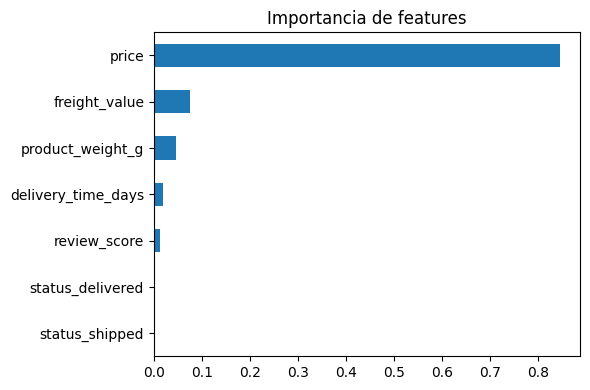

In [34]:
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot.barh(figsize=(6,4))
plt.title("Importancia de features")
plt.tight_layout()
plt.show()

In [36]:
import lightgbm as lgb
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 873
[LightGBM] [Info] Number of data points in the train set: 91870, number of used features: 5
[LightGBM] [Info] Start training from score 170.990917


LGBMRegressor(random_state=42)

In [37]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# 1) define tu TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# 2) arma el grid (elige rangos razonables)
param_dist = {
    "n_estimators":    [100, 300, 500, 1000],
    "learning_rate":   [0.01, 0.03, 0.05, 0.1],
    "num_leaves":      [31, 50, 100, 200],
    "max_depth":       [-1,  5,  10,  20],
    "min_child_samples":[5,  20,  50,  100],
    "subsample":       [0.6, 0.8, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
    "reg_alpha":       [0, 0.1, 1, 10],
    "reg_lambda":      [0, 0.1, 1, 10],
}

lgbm = LGBMRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator    = lgbm,
    param_distributions = param_dist,
    n_iter       = 30,            # número de combinaciones a probar
    cv           = tscv,
    scoring      = "neg_root_mean_squared_error",
    n_jobs       = -1,
    verbose      = 2,
    random_state = 42
)

search.fit(X_train, y_train)
best_lgbm = search.best_estimator_
print("Mejores params LGBM:", search.best_params_)

# Evalúa en test
y_pred = best_lgbm.predict(X_test)
print("RMSE (test):", mean_squared_error(y_test, y_pred, squared=False))
print("R²   (test):", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 873
[LightGBM] [Info] Number of data points in the train set: 91870, number of used features: 5
[LightGBM] [Info] Start training from score 170.990917
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

c:\Users\fdcontreras\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
df["y_log"] = np.log1p(df["payment_value"])


In [39]:
df["dow"]   = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2*np.pi*df["dow"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["dow"]/7)
df["month"] = df["date"].dt.month
df["mon_sin"] = np.sin(2*np.pi*df["month"]/12)
df["mon_cos"] = np.cos(2*np.pi*df["month"]/12)
df["is_weekend"] = df["dow"].isin([5,6]).astype(int)


In [40]:
for lag in [1,7,14,28]:
    df[f"lag_{lag}"] = df["payment_value"].shift(lag)
for window in [7,14,28]:
    df[f"roll_mean_{window}"] = (
        df["payment_value"].shift(1)
          .rolling(window)
          .mean()
    )


In [41]:
import holidays
br_hols = holidays.Brazil(years=[2016,2017,2018])
df["is_holiday"] = df["date"].isin(br_hols).astype(int)
df["is_black_friday"] = (
    (df["date"].dt.month==11) &
    (df["date"].dt.weekday==4) &
    (df["date"].dt.day.between(22,28))
).astype(int)


In [42]:
prop_cols = [c for c in df.columns if c.startswith("prop_")]
df[prop_cols] = df[prop_cols].fillna(method="ffill").fillna(0)


C:\Users\fdcontreras\AppData\Local\Temp\ipykernel_1944\4145510111.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[prop_cols] = df[prop_cols].fillna(method="ffill").fillna(0)


In [43]:
feature_cols = [
    "price","freight_value","product_weight_g","delivery_time_days","review_score",
    "dow_sin","dow_cos","mon_sin","mon_cos","is_weekend",
    "is_holiday","is_black_friday",
    *[f"lag_{l}" for l in [1,7,14,28]],
    *[f"roll_mean_{w}" for w in [7,14,28]],
    *prop_cols
]

# Elimina filas con NaN (por los lags iniciales)
df2 = df.dropna(subset=feature_cols + ["y_log"]).copy()

X = df2[feature_cols]
y = df2["y_log"]


In [44]:
split_date = "2018-01-01"
train_mask = df2["date"] < split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]


In [45]:
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    "n_estimators":       [200, 500, 800, 1200],
    "learning_rate":      [0.005, 0.01, 0.03, 0.05],
    "num_leaves":         [31, 50, 80, 120],
    "max_depth":          [5, 10, 15, 20],
    "min_child_samples":  [20, 50, 100],
    "subsample":          [0.7, 0.8, 1.0],
    "colsample_bytree":   [0.7, 0.8, 1.0],
    "reg_alpha":          [0, 0.1, 1],
    "reg_lambda":         [0, 0.1, 1, 10],
}

lgbm = LGBMRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator            = lgbm,
    param_distributions  = param_dist,
    n_iter               = 40,
    cv                   = tscv,
    scoring              = "neg_root_mean_squared_error",
    n_jobs               = -1,
    verbose              = 2,
    random_state         = 42,
)
search.fit(X_train, y_train)
best = search.best_estimator_
print("Mejores params:", search.best_params_)

# Evalúa en test
y_pred_log = best.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

rmse = mean_squared_error(y_true, y_pred, squared=False)
r2   = r2_score(y_true, y_pred)
print(f"RMSE test (orig scale): {rmse:.2f}")
print(f"R²   test:            {r2:.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2689
[LightGBM] [Info] Number of data points in the train set: 52418, number of used features: 19
[LightGBM] [Info] Start training from score 4.666831
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

c:\Users\fdcontreras\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [50]:
# 1. Crea el modelo con los mejores parámetros
final_lgbm = LGBMRegressor(
    subsample          = 0.7,
    reg_lambda         = 1,
    reg_alpha          = 0,
    num_leaves         = 31,
    n_estimators       = 1200,
    min_child_samples  = 100,
    max_depth          = 5,
    learning_rate      = 0.005,
    colsample_bytree   = 1.0,
    random_state       = 42
)

dups = X_train.columns[X_train.columns.duplicated()]
print("Columnas duplicadas:", dups.tolist())

# 2) Quitar las columnas repetidas (se queda sólo la primera aparición)
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test  = X_test.loc[:, ~X_test.columns.duplicated()]

# 3) Volver a entrenar
final_lgbm.fit(X_train, y_train)

Columnas duplicadas: ['status_delivered', 'status_shipped']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 95314, number of used features: 10
[LightGBM] [Info] Start training from score 172.264731
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

LGBMRegressor(learning_rate=0.005, max_depth=5, min_child_samples=100,
              n_estimators=1200, random_state=42, reg_alpha=0, reg_lambda=1,
              subsample=0.7)

In [51]:
print("Parámetros del modelo final:")
print(final_lgbm.get_params())

Parámetros del modelo final:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.005, 'max_depth': 5, 'min_child_samples': 100, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 1200, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.7, 'subsample_for_bin': 200000, 'subsample_freq': 0}


Top 10 features por importancia:
price                 6962
freight_value         5140
product_weight_g      3371
review_score          2245
delivery_time_days    2214
dow                    809
month                  730
status_shipped         166
status_delivered        44
is_weekend               0
dtype: int32


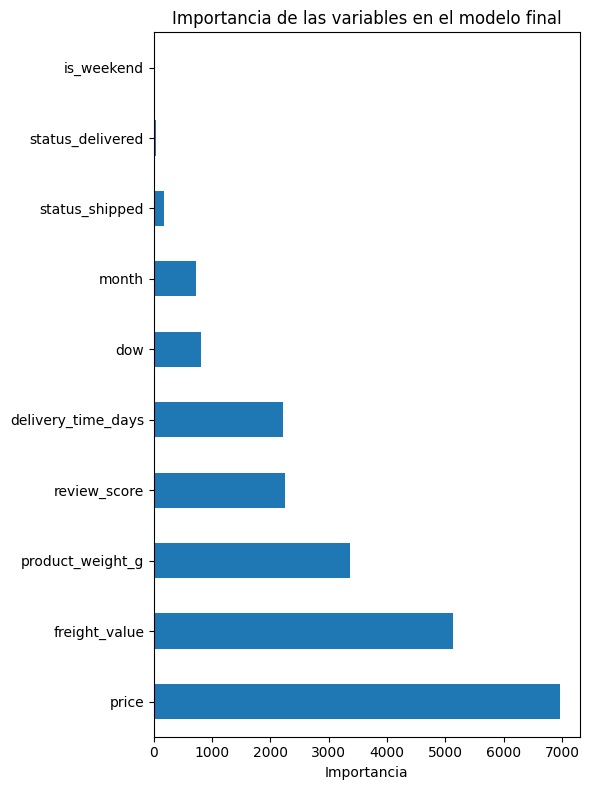

In [52]:
importances = pd.Series(final_lgbm.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print("Top 10 features por importancia:")
print(importances.head(10))

# Gráfico
importances.plot.barh(figsize=(6,8))
plt.title("Importancia de las variables en el modelo final")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Modelo

In [68]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR

In [69]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

In [70]:
# Split temporal (NO aleatorio)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [71]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse, 
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2
    }

### Opción de manejo de datos en Oct 2018

(114786, 69)


In [75]:
# 1. Asegurar que la columna date sea datetime
if data['date'].dtype == 'object':
    data['date'] = pd.to_datetime(data['date'])

# 2. Filtrar datos antes de la caída (excluir oct 2018 en adelante)
data_clean = data[data['date'] < pd.to_datetime('2018-10-01')].copy()

# 3. Crear dataset mensual agregado
monthly_data = data_clean.groupby([
    data_clean['date'].dt.year, 
    data_clean['date'].dt.month
]).agg({
    'payment_value': ['count', 'sum', 'mean'],
    'customer_unique_id': 'nunique'
}).reset_index()

# 4. Limpiar nombres de columnas
monthly_data.columns = [
    'year', 'month', 'num_transactions', 'total_sales', 
    'avg_transaction', 'unique_customers'
]

# 5. Crear columna de fecha
monthly_data['date'] = pd.to_datetime(monthly_data[['year', 'month']])

# 6. Ver el resultado
print("Dataset mensual creado:")
print(monthly_data.head())
print(f"\nShape: {monthly_data.shape}")

TypeError: list indices must be integers or slices, not str

In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_sales, model='additive')

# Features estacionales
data['seasonal_component'] = decomposition.seasonal
data['trend_component'] = decomposition.trend

NameError: name 'monthly_sales' is not defined